# HW12.ipynb

Готовый ноутбук для HW12. После `Run All` он пересчитает baseline'ы, обучит `GRU`, сохранит `runs.csv`, `best_gru.pt`, `best_gru_config.json` и графики в `./artifacts/`.

In [1]:
from pathlib import Path
import os, json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)

BASE_DIR = Path.cwd()
ART_DIR = BASE_DIR / "artifacts"
FIG_DIR = ART_DIR / "figures"
ART_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

DATA_PATH = BASE_DIR / "S12-hw-dataset.csv"
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"


device = cpu


shape: (4320, 2)
date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00

missing values:
date      0
target    0
dtype: int64


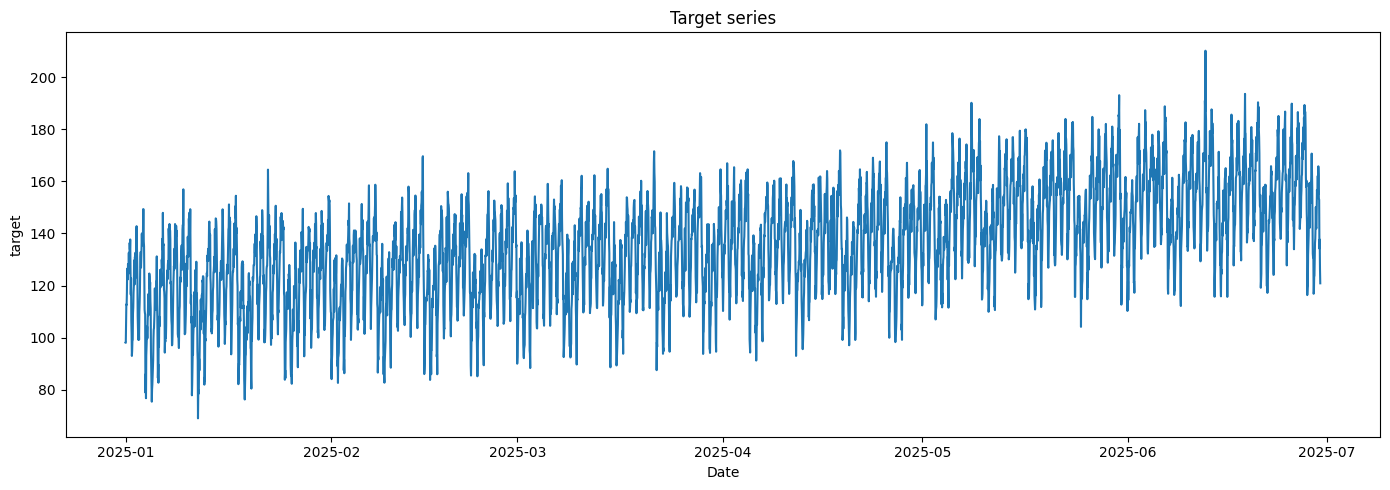

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

print("shape:", df.shape)
print("date range:", df["date"].min(), "->", df["date"].max())
print("\nmissing values:")
print(df.isna().sum())

plt.figure(figsize=(14, 5))
plt.plot(df["date"], df["target"])
plt.title("Target series")
plt.xlabel("Date")
plt.ylabel("target")
plt.tight_layout()
plt.show()


## Комментарий к данным

Ряд почасовой и без пропусков. Для такой задачи нельзя использовать `random split`, потому что он перемешивает прошлое и будущее и искажает реальное качество прогноза.

train: 2025-01-01 00:00:00 -> 2025-04-30 23:00:00 2880
val:   2025-05-01 00:00:00 -> 2025-05-30 23:00:00 720
test:  2025-05-31 00:00:00 -> 2025-06-29 23:00:00 720


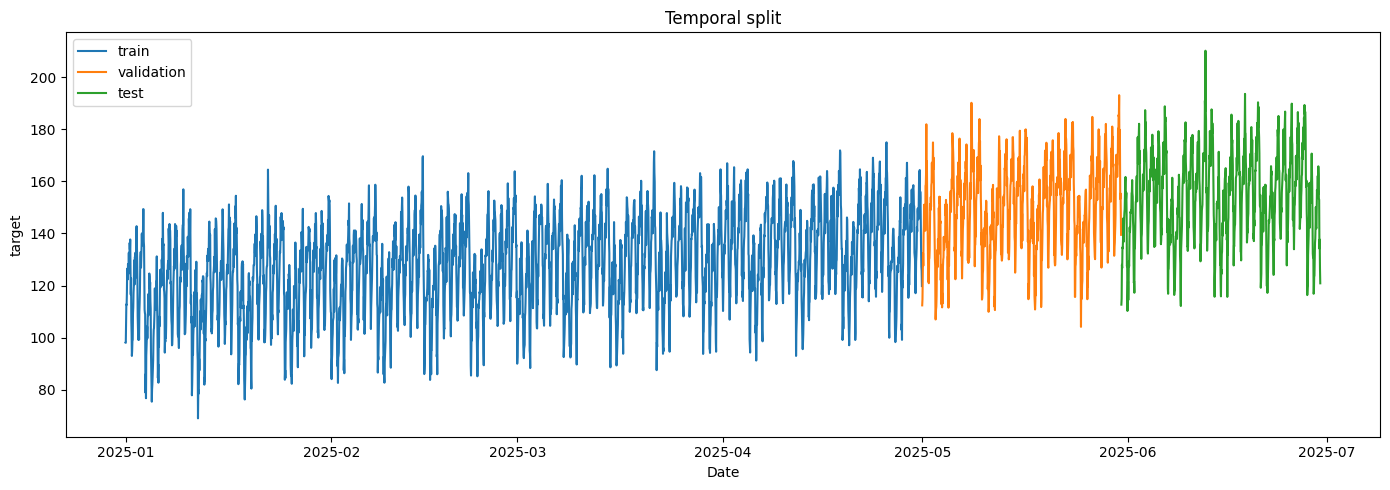

In [3]:
train_end = 24 * 120
val_end = train_end + 24 * 30

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("train:", train_df["date"].min(), "->", train_df["date"].max(), len(train_df))
print("val:  ", val_df["date"].min(), "->", val_df["date"].max(), len(val_df))
print("test: ", test_df["date"].min(), "->", test_df["date"].max(), len(test_df))

plt.figure(figsize=(14, 5))
plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="validation")
plt.plot(test_df["date"], test_df["target"], label="test")
plt.title("Temporal split")
plt.xlabel("Date")
plt.ylabel("target")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "series_split.png", dpi=150)
plt.show()


In [4]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(math.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0)
    return mae, rmse, mape

naive_pred = df["target"].shift(1)
b1_val = compute_metrics(val_df["target"], naive_pred.iloc[train_end:val_end])
print("B1 val:", b1_val)

ma_window = 3
ma_pred = df["target"].shift(1).rolling(ma_window).mean()
b2_val = compute_metrics(val_df["target"], ma_pred.iloc[train_end:val_end])
print("B2 val:", b2_val)


B1 val: (6.570222222222221, 8.308676455636268, 4.496575277909907)
B2 val: (8.308337962962966, 10.128130452657556, 5.73212460697731)


In [5]:
def make_feature_frame(dataframe):
    out = dataframe.copy()
    out["lag_1"] = out["target"].shift(1)
    out["lag_7"] = out["target"].shift(7)
    out["lag_14"] = out["target"].shift(14)
    out["lag_24"] = out["target"].shift(24)
    out["lag_168"] = out["target"].shift(168)
    out["rolling_mean_7"] = out["target"].shift(1).rolling(7).mean()
    out["rolling_std_7"] = out["target"].shift(1).rolling(7).std()
    out["rolling_mean_24"] = out["target"].shift(1).rolling(24).mean()
    out["rolling_std_24"] = out["target"].shift(1).rolling(24).std()
    out["hour"] = out["date"].dt.hour
    out["dayofweek"] = out["date"].dt.dayofweek
    out["dayofmonth"] = out["date"].dt.day
    out["month"] = out["date"].dt.month
    return out

feat_df = make_feature_frame(df).dropna().reset_index(drop=True)

train_mask = feat_df["date"] <= train_df["date"].max()
val_mask = (feat_df["date"] >= val_df["date"].min()) & (feat_df["date"] <= val_df["date"].max())
test_mask = feat_df["date"] >= test_df["date"].min()

feature_cols = [c for c in feat_df.columns if c not in ["date", "target"]]

X_train = feat_df.loc[train_mask, feature_cols]
y_train = feat_df.loc[train_mask, "target"]
X_val = feat_df.loc[val_mask, feature_cols]
y_val = feat_df.loc[val_mask, "target"]
X_test = feat_df.loc[test_mask, feature_cols]
y_test = feat_df.loc[test_mask, "target"]

ridge_scaler = StandardScaler()
X_train_scaled = ridge_scaler.fit_transform(X_train)
X_val_scaled = ridge_scaler.transform(X_val)
X_test_scaled = ridge_scaler.transform(X_test)

ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)

b3_val_pred = ridge_model.predict(X_val_scaled)
b3_val = compute_metrics(y_val, b3_val_pred)
print("B3 val:", b3_val)


B3 val: (4.9827900599807595, 6.414300805025968, 3.3508229119128554)


epoch=1 val_mae=23.5278 val_rmse=27.5747 val_mape=14.8988
epoch=2 val_mae=21.7940 val_rmse=25.6824 val_mape=13.8035
epoch=3 val_mae=20.4472 val_rmse=24.1593 val_mape=12.9583
epoch=4 val_mae=19.0877 val_rmse=22.6110 val_mape=12.1084
epoch=5 val_mae=17.5703 val_rmse=20.8883 val_mape=11.1637
epoch=6 val_mae=16.0551 val_rmse=19.1139 val_mape=10.2297
epoch=7 val_mae=14.5268 val_rmse=17.2729 val_mape=9.3010
epoch=8 val_mae=13.1403 val_rmse=15.6127 val_mape=8.4629
R1 val: (13.14034620920817, 15.612731219260176, 8.462919676038041)


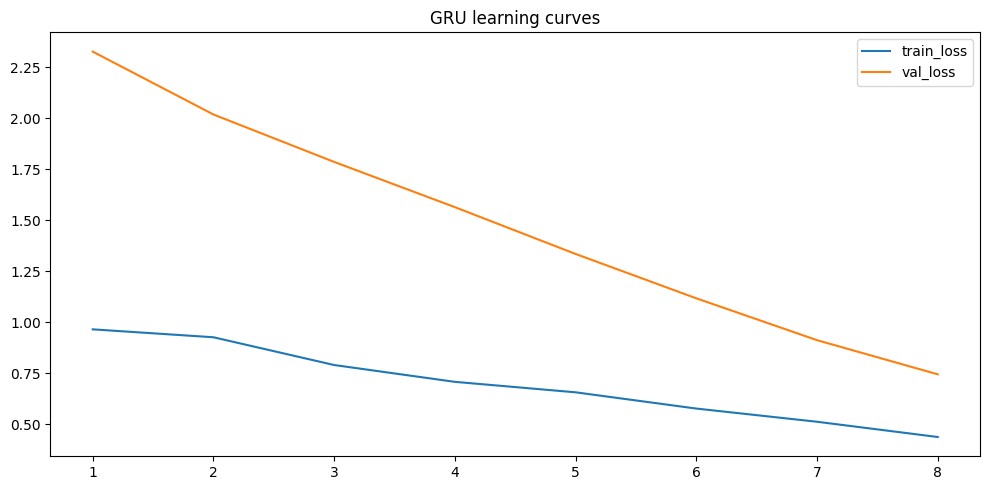

In [6]:
class SequenceDataset(Dataset):
    def __init__(self, values, window_size):
        X, y = [], []
        for i in range(window_size, len(values)):
            X.append(values[i-window_size:i])
            y.append(values[i])
        self.X = torch.tensor(np.asarray(X, dtype=np.float32)[:, :, None])
        self.y = torch.tensor(np.asarray(y, dtype=np.float32)[:, None])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :])

window_size = 48
batch_size = 256
max_epochs = 8
learning_rate = 1e-3
patience = 3
hidden_size = 16

target_scaler = StandardScaler()
train_scaled = target_scaler.fit_transform(train_df[["target"]]).reshape(-1)
val_scaled = target_scaler.transform(val_df[["target"]]).reshape(-1)

gru_train_ds = SequenceDataset(train_scaled, window_size)
gru_val_ds = SequenceDataset(np.concatenate([train_scaled[-window_size:], val_scaled]), window_size)

gru_train_loader = DataLoader(gru_train_ds, batch_size=batch_size, shuffle=True)
gru_val_loader = DataLoader(gru_val_ds, batch_size=batch_size, shuffle=False)

gru_model = GRUForecaster(hidden_size=hidden_size).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=learning_rate)

history = []
best_val_mae = float("inf")
best_state = None
bad_epochs = 0

for epoch in range(1, max_epochs + 1):
    gru_model.train()
    train_losses = []

    for xb, yb in gru_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = gru_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    gru_model.eval()
    val_losses = []
    preds_scaled = []
    true_scaled = []
    with torch.no_grad():
        for xb, yb in gru_val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds = gru_model(xb)
            val_losses.append(criterion(preds, yb).item())
            preds_scaled.append(preds.cpu().numpy())
            true_scaled.append(yb.cpu().numpy())

    preds_scaled = np.concatenate(preds_scaled).reshape(-1, 1)
    true_scaled = np.concatenate(true_scaled).reshape(-1, 1)
    preds = target_scaler.inverse_transform(preds_scaled).reshape(-1)
    true = target_scaler.inverse_transform(true_scaled).reshape(-1)

    val_mae, val_rmse, val_mape = compute_metrics(true, preds)
    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_loss": float(np.mean(val_losses)),
        "val_mae": val_mae,
        "val_rmse": val_rmse,
        "val_mape": val_mape,
    })
    print(f"epoch={epoch} val_mae={val_mae:.4f} val_rmse={val_rmse:.4f} val_mape={val_mape:.4f}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.detach().cpu().clone() for k, v in gru_model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            break

gru_model.load_state_dict(best_state)
torch.save(best_state, ART_DIR / "best_gru.pt")

best_hist_row = min(history, key=lambda x: x["val_mae"])
r1_val = (best_hist_row["val_mae"], best_hist_row["val_rmse"], best_hist_row["val_mape"])
print("R1 val:", r1_val)

hist_df = pd.DataFrame(history)
plt.figure(figsize=(10, 5))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
plt.legend()
plt.title("GRU learning curves")
plt.tight_layout()
plt.savefig(FIG_DIR / "gru_learning_curves.png", dpi=150)
plt.show()

cfg = {
    "model_name": "GRUForecaster",
    "window_size": window_size,
    "horizon": 1,
    "input_size": 1,
    "hidden_size": hidden_size,
    "num_layers": 1,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "max_epochs": max_epochs,
    "optimizer": "Adam",
    "criterion": "MSELoss",
    "scaler": "StandardScaler(train target only)",
    "seed": SEED,
    "device": device,
}
with open(ART_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(cfg, f, ensure_ascii=False, indent=2)


best_experiment_id = B3
test metrics: (4.3668976599267255, 5.64598056006382, 2.8389316770400264)


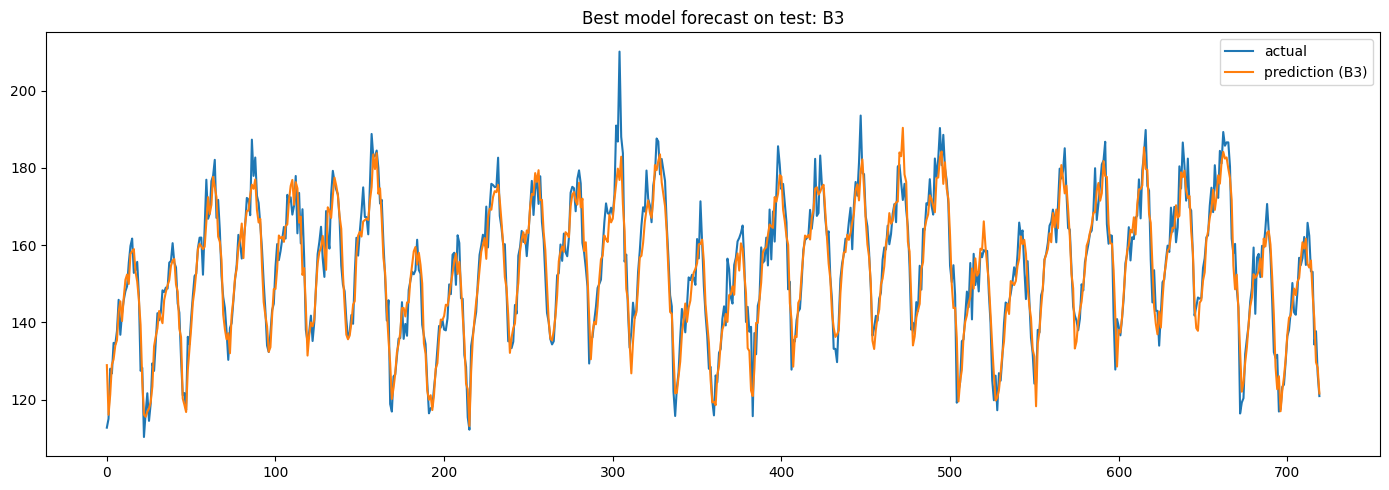

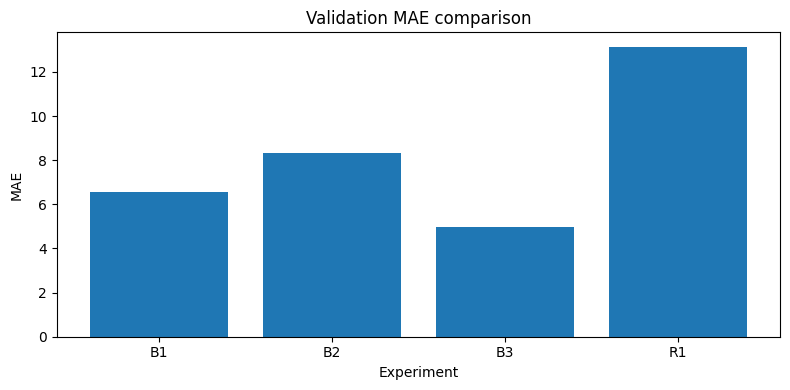

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"train=2880, val=720, test=720",,1,naive-last,last observed target,,,,,6.570222,8.308676,4.496575,,,,validation baseline
1,B2,forecasting,S12-hw-dataset.csv,42,"train=2880, val=720, test=720",3,1,moving-average,rolling mean,,,,,8.308338,10.128130,5.732125,,,,validation baseline
2,B3,forecasting,S12-hw-dataset.csv,42,"train=2880, val=720, test=720",,1,Ridge(alpha=0.1),lags + rolling + calendar,StandardScaler(train only),,,,4.982790,6.414301,3.350823,4.366898,5.645981,2.838932,tabular baseline
3,R1,forecasting,S12-hw-dataset.csv,42,"train=2880, val=720, test=720",48,1,GRU(hidden_size=16),target-only sliding windows,StandardScaler(train target only),Adam,0.001,8,13.140346,15.612731,8.462920,,,,GRU forecast


In [7]:
val_summary = {"B1": b1_val, "B2": b2_val, "B3": b3_val, "R1": r1_val}
best_experiment_id = min(val_summary, key=lambda k: val_summary[k][0])
print("best_experiment_id =", best_experiment_id)

test_metrics = {"B1": ("", "", ""), "B2": ("", "", ""), "B3": ("", "", ""), "R1": ("", "", "")}

if best_experiment_id == "B1":
    best_test_true = test_df["target"].to_numpy()
    best_test_pred = df["target"].shift(1).iloc[val_end:].to_numpy()
    test_metrics["B1"] = compute_metrics(best_test_true, best_test_pred)

elif best_experiment_id == "B2":
    best_test_true = test_df["target"].to_numpy()
    best_test_pred = df["target"].shift(1).rolling(ma_window).mean().iloc[val_end:].to_numpy()
    test_metrics["B2"] = compute_metrics(best_test_true, best_test_pred)

elif best_experiment_id == "B3":
    best_test_true = y_test.to_numpy()
    best_test_pred = ridge_model.predict(X_test_scaled)
    test_metrics["B3"] = compute_metrics(best_test_true, best_test_pred)

else:
    test_scaled = target_scaler.transform(test_df[["target"]]).reshape(-1)
    gru_test_ds = SequenceDataset(np.concatenate([val_scaled[-window_size:], test_scaled]), window_size)
    gru_test_loader = DataLoader(gru_test_ds, batch_size=batch_size, shuffle=False)
    preds_scaled, true_scaled = [], []
    gru_model.eval()
    with torch.no_grad():
        for xb, yb in gru_test_loader:
            xb = xb.to(device)
            preds = gru_model(xb)
            preds_scaled.append(preds.cpu().numpy())
            true_scaled.append(yb.numpy())
    preds_scaled = np.concatenate(preds_scaled).reshape(-1, 1)
    true_scaled = np.concatenate(true_scaled).reshape(-1, 1)
    best_test_pred = target_scaler.inverse_transform(preds_scaled).reshape(-1)
    best_test_true = target_scaler.inverse_transform(true_scaled).reshape(-1)
    test_metrics["R1"] = compute_metrics(best_test_true, best_test_pred)

print("test metrics:", test_metrics[best_experiment_id])

plt.figure(figsize=(14, 5))
plt.plot(best_test_true, label="actual")
plt.plot(best_test_pred, label=f"prediction ({best_experiment_id})")
plt.legend()
plt.title(f"Best model forecast on test: {best_experiment_id}")
plt.tight_layout()
plt.savefig(FIG_DIR / "best_forecast_test.png", dpi=150)
plt.show()

compare_df = pd.DataFrame({
    "experiment_id": list(val_summary.keys()),
    "val_mae": [v[0] for v in val_summary.values()],
})
plt.figure(figsize=(8, 4))
plt.bar(compare_df["experiment_id"], compare_df["val_mae"])
plt.title("Validation MAE comparison")
plt.xlabel("Experiment")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig(FIG_DIR / "baselines_compare.png", dpi=150)
plt.show()

runs = pd.DataFrame([
    {"experiment_id": "B1", "task": "forecasting", "dataset": "S12-hw-dataset.csv", "seed": SEED,
     "split_summary": f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}",
     "window_size": "", "horizon": 1, "model_summary": "naive-last",
     "features_summary": "last observed target", "scaler": "", "optimizer": "", "lr": "", "epochs_trained": "",
     "best_val_mae": b1_val[0], "best_val_rmse": b1_val[1], "best_val_mape": b1_val[2],
     "test_mae": test_metrics["B1"][0], "test_rmse": test_metrics["B1"][1], "test_mape": test_metrics["B1"][2],
     "notes": "validation baseline"},
    {"experiment_id": "B2", "task": "forecasting", "dataset": "S12-hw-dataset.csv", "seed": SEED,
     "split_summary": f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}",
     "window_size": ma_window, "horizon": 1, "model_summary": "moving-average",
     "features_summary": "rolling mean", "scaler": "", "optimizer": "", "lr": "", "epochs_trained": "",
     "best_val_mae": b2_val[0], "best_val_rmse": b2_val[1], "best_val_mape": b2_val[2],
     "test_mae": test_metrics["B2"][0], "test_rmse": test_metrics["B2"][1], "test_mape": test_metrics["B2"][2],
     "notes": "validation baseline"},
    {"experiment_id": "B3", "task": "forecasting", "dataset": "S12-hw-dataset.csv", "seed": SEED,
     "split_summary": f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}",
     "window_size": "", "horizon": 1, "model_summary": "Ridge(alpha=0.1)",
     "features_summary": "lags + rolling + calendar", "scaler": "StandardScaler(train only)",
     "optimizer": "", "lr": "", "epochs_trained": "",
     "best_val_mae": b3_val[0], "best_val_rmse": b3_val[1], "best_val_mape": b3_val[2],
     "test_mae": test_metrics["B3"][0], "test_rmse": test_metrics["B3"][1], "test_mape": test_metrics["B3"][2],
     "notes": "tabular baseline"},
    {"experiment_id": "R1", "task": "forecasting", "dataset": "S12-hw-dataset.csv", "seed": SEED,
     "split_summary": f"train={len(train_df)}, val={len(val_df)}, test={len(test_df)}",
     "window_size": window_size, "horizon": 1, "model_summary": f"GRU(hidden_size={hidden_size})",
     "features_summary": "target-only sliding windows", "scaler": "StandardScaler(train target only)",
     "optimizer": "Adam", "lr": learning_rate, "epochs_trained": len(history),
     "best_val_mae": r1_val[0], "best_val_rmse": r1_val[1], "best_val_mape": r1_val[2],
     "test_mae": test_metrics["R1"][0], "test_rmse": test_metrics["R1"][1], "test_mape": test_metrics["R1"][2],
     "notes": "GRU forecast"},
])
runs.to_csv(ART_DIR / "runs.csv", index=False)
runs
